<a href="https://colab.research.google.com/github/Thota-Akhilasri/OIBSIP/blob/main/DataScience-Task4-EmailSpamDetection/Akhilasri_Thota_Task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
#Load Dataset
df = pd.read_csv("spam.csv", encoding="latin-1")
df = df[['v1','v2']]
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
#Dataset Information
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Missing Values:
label      0
message    0
dtype: int64

First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


label
ham     4825
spam     747
Name: count, dtype: int64


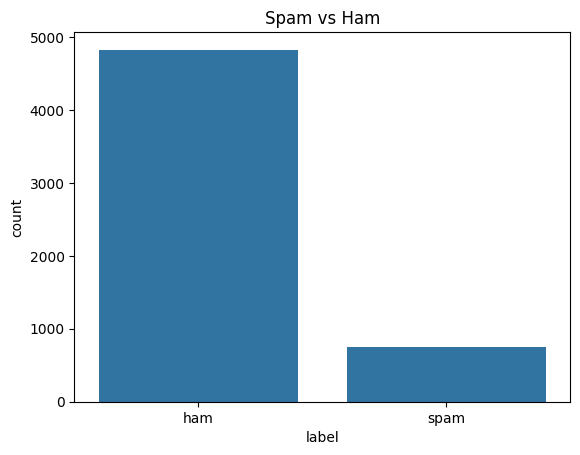

In [ ]:
#Class Distribution
print(df['label'].value_counts())
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham")
plt.show()

**Conclusion** : The dataset indicates the amount of spam and ham messages.

In [ ]:
#Text Preprocessing
stop_words = set(stopwords.words('english'))
def clean_text(text):
  text = text.lower()
  text = re.sub(r'[^a-zA-Z]', ' ', text)
  words = text.split()
  words = [word for word in words if word not in stop_words]
  return " ".join(words)
df['clean_message'] = df['message'].apply(clean_text)
df.head()

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though


**Conclusion** : The text preprocessing step cleaned the email messages by removing unnecessary words and characters.This makes the data more suitable for accurate spam detection.

In [ ]:
print(df.columns)

Index(['label', 'message', 'clean_message'], dtype='object')


In [ ]:
#TF-IDF Vecorization
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['clean_message'])
y = df['label']

In [ ]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#Multinomial Navie Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.9668161434977578
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



**Conclusion** : The multinomial naive bayes model achieved about 97% accuracy and performed very well in detecting spam and ham emails.

In [ ]:
#Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9479820627802691
              precision    recall  f1-score   support

         ham       0.95      0.99      0.97       965
        spam       0.95      0.65      0.77       150

    accuracy                           0.95      1115
   macro avg       0.95      0.82      0.87      1115
weighted avg       0.95      0.95      0.94      1115



**Conclusion** : The Logistic Regression model performed well with about 95% accuracy. The evaluation metrices show that it correctly classified most spam or ham messages, making it a reliable model for email spam detection.

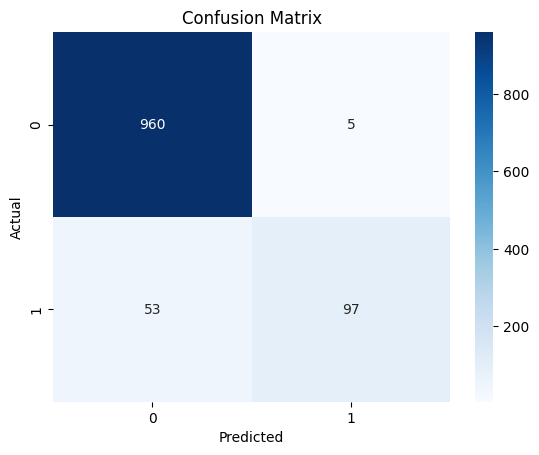

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Conclusion** : The confusion matrix compares the actual labels with the predicted labels.It shows the most emails were correctly classified as spam or ham.

In [ ]:
#Model Comparison
comparison = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred)
    ]
})

print(comparison)

                 Model  Accuracy
0          Naive Bayes  0.966816
1  Logistic Regression  0.947982


**Conclusion** : The  model with the higher accuracy performanace and is more suitable for spam detection.

In [ ]:
#Predict New Message
sample = ["Congratulations! You have won a free iphone. Claim now!"]
sample = tfidf.transform(sample)
prediction = lr_model.predict(sample)
print("Prediction:", prediction[0])

Prediction: spam


**Conclusion** : This project successfully classified emails into spam and ham using NLP and Machine Learning. After preprocessing the text and applying TF-IDF, the models were trained and tested. The evaluation results showed good performance, making the system useful for identifying spam messages automatically.